<a href="https://colab.research.google.com/github/ChrisEsau/ufc-ai-clv-tracker/blob/dev/UFC_backtest_V5_refactored.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SECTION 1 — LOAD UFC MASTER FILE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("/content/drive/MyDrive/UFC_AI")
from ufc_pipeline_utils import *

paths = UFCPipelinePaths(
    base_path="/content/drive/MyDrive/UFC_AI",
    model_version="UFC_Model_v5_Experiment"
)

BASE_PATH = paths.base_path
PRODUCTION_DIR = paths.production_dir

# Change this if your file has a different name
MASTER_PATH = f"{BASE_PATH}/ufc-master.csv"

# If unsure, search for possible CSV files
if not os.path.exists(MASTER_PATH):
    for root, dirs, files in os.walk(BASE_PATH):
        for file in files:
            if file.lower().endswith(".csv"):
                print(os.path.join(root, file))

df_master = pd.read_csv(MASTER_PATH)

print("Master shape:", df_master.shape)
df_master.head()


Mounted at /content/drive
Master shape: (7177, 118)


,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


In [ ]:
# ============================================================
# SECTION 2 — INSPECT MASTER COLUMNS
# ============================================================

for col in df_master.columns:
    print(col)

R_fighter
B_fighter
R_odds
B_odds
R_ev
B_ev
date
location
country
Winner
title_bout
weight_class
gender
no_of_rounds
B_current_lose_streak
B_current_win_streak
B_draw
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_longest_win_streak
B_losses
B_total_rounds_fought
B_total_title_bouts
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_Stance
B_Height_cms
B_Reach_cms
B_Weight_lbs
R_current_lose_streak
R_current_win_streak
R_draw
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_longest_win_streak
R_losses
R_total_rounds_fought
R_total_title_bouts
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_wins
R_Stance
R_Height_cms
R_Reach_cms
R_Weight_lbs
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_

In [ ]:
# ============================================================
# SECTION 4 — NAME NORMALIZATION
# ============================================================

# normalize_name is imported from ufc_pipeline_utils.py.
print("Using shared normalize_name() from ufc_pipeline_utils.py")


Using shared normalize_name() from ufc_pipeline_utils.py


In [ ]:
# ============================================================
# SECTION 5 — EXTRACT HISTORICAL MONEYLINE ODDS
# ============================================================

odds_hist = pd.DataFrame()

odds_hist["date"] = pd.to_datetime(
    df_master["date"],
    errors="coerce"
)

odds_hist["red_fighter"] = df_master["R_fighter"]
odds_hist["blue_fighter"] = df_master["B_fighter"]

odds_hist["winner"] = df_master["Winner"]

odds_hist["red_odds"] = pd.to_numeric(
    df_master["R_odds"],
    errors="coerce"
)

odds_hist["blue_odds"] = pd.to_numeric(
    df_master["B_odds"],
    errors="coerce"
)

odds_hist["red_norm"] = odds_hist["red_fighter"].apply(normalize_name)
odds_hist["blue_norm"] = odds_hist["blue_fighter"].apply(normalize_name)

# Target:
# 1 = red won
# 0 = blue won
odds_hist["actual_red_win"] = (
    odds_hist["winner"].astype(str).str.lower() == "red"
).astype(int)

# Drop fights with missing moneyline odds
odds_hist = odds_hist.dropna(
    subset=[
        "date",
        "red_odds",
        "blue_odds"
    ]
).copy()

print("Historical odds rows:", len(odds_hist))

odds_hist.head()

Historical odds rows: 6924


,date,red_fighter,blue_fighter,winner,red_odds,blue_odds,red_norm,blue_norm,actual_red_win
0,2026-03-28,Israel Adesanya,Joe Pyfer,Blue,-130.0,102.0,israel adesanya,joe pyfer,0
1,2026-03-28,Alexa Grasso,Maycee Barber,Red,124.0,-158.0,alexa grasso,maycee barber,1
2,2026-03-28,Michael Chiesa,Niko Price,Red,-901.0,550.0,michael chiesa,niko price,1
3,2026-03-28,Julian Erosa,Lerryan Douglas,Blue,235.0,-320.0,julian erosa,lerryan douglas,0
4,2026-03-28,Mansur Abdul-Malik,Yousri Belgaroui,Blue,-158.0,124.0,mansur abdul malik,yousri belgaroui,0


In [ ]:
# ============================================================
# SECTION 6 — AMERICAN ODDS HELPERS
# ============================================================

# american_to_decimal and american_to_implied_prob are imported from ufc_pipeline_utils.py.

odds_hist["red_decimal_odds"] = odds_hist["red_odds"].apply(
    american_to_decimal
)

odds_hist["blue_decimal_odds"] = odds_hist["blue_odds"].apply(
    american_to_decimal
)

odds_hist["red_implied_prob"] = odds_hist["red_odds"].apply(
    american_to_implied_prob
)

odds_hist["blue_implied_prob"] = odds_hist["blue_odds"].apply(
    american_to_implied_prob
)

odds_hist.head()


,date,red_fighter,blue_fighter,winner,red_odds,blue_odds,red_norm,blue_norm,actual_red_win,red_decimal_odds,blue_decimal_odds,red_implied_prob,blue_implied_prob
0,2026-03-28,Israel Adesanya,Joe Pyfer,Blue,-130.0,102.0,israel adesanya,joe pyfer,0,1.769231,2.020000,0.565217,0.495050
1,2026-03-28,Alexa Grasso,Maycee Barber,Red,124.0,-158.0,alexa grasso,maycee barber,1,2.240000,1.632911,0.446429,0.612403
2,2026-03-28,Michael Chiesa,Niko Price,Red,-901.0,550.0,michael chiesa,niko price,1,1.110988,6.500000,0.900100,0.153846
3,2026-03-28,Julian Erosa,Lerryan Douglas,Blue,235.0,-320.0,julian erosa,lerryan douglas,0,3.350000,1.312500,0.298507,0.761905
4,2026-03-28,Mansur Abdul-Malik,Yousri Belgaroui,Blue,-158.0,124.0,mansur abdul malik,yousri belgaroui,0,1.632911,2.240000,0.612403,0.446429


In [ ]:
# ============================================================
# SECTION 7 — SAVE CLEAN HISTORICAL ODDS FILE
# ============================================================

HISTORICAL_ODDS_OUTPUT = f"{BASE_PATH}/ufc_historical_moneyline_odds_clean.csv"

odds_hist.to_csv(
    HISTORICAL_ODDS_OUTPUT,
    index=False
)

print("Saved historical odds file to:")
print(HISTORICAL_ODDS_OUTPUT)

Saved historical odds file to:
/content/drive/MyDrive/UFC_AI/ufc_historical_moneyline_odds_clean.csv


In [ ]:
# ============================================================
# SECTION 8 — FILTER TO COMPLETED HISTORICAL ODDS ONLY
# ============================================================

TODAY = pd.Timestamp.today().normalize()

odds_hist_completed = odds_hist[
    (odds_hist["date"] < TODAY)
    &
    (odds_hist["winner"].isin(["Red", "Blue"]))
].copy()

print("All odds rows:", len(odds_hist))
print("Completed historical rows:", len(odds_hist_completed))

odds_hist_completed.head()

All odds rows: 6924
Completed historical rows: 6916


,date,red_fighter,blue_fighter,winner,red_odds,blue_odds,red_norm,blue_norm,actual_red_win,red_decimal_odds,blue_decimal_odds,red_implied_prob,blue_implied_prob
0,2026-03-28,Israel Adesanya,Joe Pyfer,Blue,-130.0,102.0,israel adesanya,joe pyfer,0,1.769231,2.020000,0.565217,0.495050
1,2026-03-28,Alexa Grasso,Maycee Barber,Red,124.0,-158.0,alexa grasso,maycee barber,1,2.240000,1.632911,0.446429,0.612403
2,2026-03-28,Michael Chiesa,Niko Price,Red,-901.0,550.0,michael chiesa,niko price,1,1.110988,6.500000,0.900100,0.153846
3,2026-03-28,Julian Erosa,Lerryan Douglas,Blue,235.0,-320.0,julian erosa,lerryan douglas,0,3.350000,1.312500,0.298507,0.761905
4,2026-03-28,Mansur Abdul-Malik,Yousri Belgaroui,Blue,-158.0,124.0,mansur abdul malik,yousri belgaroui,0,1.632911,2.240000,0.612403,0.446429


In [ ]:
# ============================================================
# SECTION 9 — SAVE COMPLETED HISTORICAL ODDS ONLY
# ============================================================

HISTORICAL_ODDS_COMPLETED_OUTPUT = (
    f"{BASE_PATH}/ufc_historical_moneyline_odds_completed.csv"
)

odds_hist_completed.to_csv(
    HISTORICAL_ODDS_COMPLETED_OUTPUT,
    index=False
)

print("Saved completed historical odds file to:")
print(HISTORICAL_ODDS_COMPLETED_OUTPUT)

Saved completed historical odds file to:
/content/drive/MyDrive/UFC_AI/ufc_historical_moneyline_odds_completed.csv


In [ ]:
# ============================================================
# LOAD PRODUCTION V5 ARTIFACTS
# ============================================================

artifacts = load_production_artifacts(paths)

model = artifacts["model"]
feature_columns = artifacts["feature_columns"]
BEST_THRESHOLD = artifacts["best_threshold"]
production_config = artifacts["production_config"]

betting_filters = get_betting_filters(production_config)
MIN_EDGE = betting_filters["min_edge"]
MIN_CONFIDENCE = betting_filters["min_confidence"]
MIN_ODDS = betting_filters["min_odds"]
MAX_ODDS = betting_filters["max_odds"]

KELLY_FRACTION = production_config["staking"]["kelly_fraction"]
MAX_STAKE_PCT = production_config["staking"]["max_stake_pct"]

print("Loaded production model:", PRODUCTION_DIR)
print("Feature count:", len(feature_columns))
print("Best threshold:", BEST_THRESHOLD)
print("Filters:", production_config["betting_filters"])
print("Staking:", production_config["staking"])


Loaded production model: /content/drive/MyDrive/UFC_AI/UFC_Model_v5_Experiment
Feature count: 124
Best threshold: 0.51
Filters: {'min_edge': 0.1, 'min_confidence': 65, 'min_odds': -250, 'max_odds': 200}
Staking: {'method': 'fractional_kelly', 'kelly_fraction': 0.5, 'max_stake_pct': 0.03, 'starting_bankroll': 10000}


In [ ]:
# ============================================================
# SECTION 11 — LOAD ROLLING FEATURE DATA
# ============================================================

ROLLING_PATH = paths.rolling_features_path

rolling_df = pd.read_csv(ROLLING_PATH)

rolling_df["date"] = pd.to_datetime(
    rolling_df["date"],
    errors="coerce"
)

rolling_df = rolling_df.sort_values("date").reset_index(drop=True)

rolling_df["red_norm"] = rolling_df["r_name"].apply(normalize_name)
rolling_df["blue_norm"] = rolling_df["b_name"].apply(normalize_name)

print("Rolling feature rows:", len(rolling_df))
rolling_df.head()


Rolling feature rows: 8190


,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,...,b_pressure_striking_adv,pressure_striking_adv_diff,r_wrestling_mismatch,b_wrestling_mismatch,wrestling_mismatch_diff,r_submission_mismatch,b_submission_mismatch,submission_mismatch_diff,red_norm,blue_norm
0,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",4acab67848e78327,open weight,0,Submission,1,20,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,scott morris,sean daugherty
1,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",4b9ae533ccb3fcdf,open weight,0,Submission,1,58,...,0.0,0.0,0.0,0.0,0.0,6.250000,0.0,6.250000,patrick smith,ray wizard
2,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",00835554f95fa911,2 tournament,1,KO/TKO,1,77,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,royce gracie,patrick smith
3,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",aa161c7159741766,open weight,0,Submission,1,91,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,royce gracie,remco pardoel
4,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",5655639baecd8f6a,open weight,0,Submission,1,67,...,0.0,0.0,0.0,0.0,0.0,5.357143,0.0,5.357143,royce gracie,jason delucia


In [ ]:
# ============================================================
# SECTION 12 — VALIDATE MODEL FEATURES EXIST
# ============================================================

missing_features = [
    col for col in feature_columns
    if col not in rolling_df.columns
]

if missing_features:
    print("Missing model features:")
    print(missing_features)
    raise ValueError("Backtest rolling data is missing required model features.")

print("All model features found.")
print("Feature count:", len(feature_columns))

All model features found.
Feature count: 124


In [ ]:
# ============================================================
# SECTION 13 — MERGE MODEL FEATURES WITH HISTORICAL ODDS
# ============================================================
# Merges by:
# - date
# - red fighter normalized name
# - blue fighter normalized name
# ============================================================

backtest_df = rolling_df.merge(
    odds_hist_completed,
    left_on=[
        "date",
        "red_norm",
        "blue_norm"
    ],
    right_on=[
        "date",
        "red_norm",
        "blue_norm"
    ],
    how="inner",
    suffixes=("", "_odds")
)

print("Merged backtest rows:", len(backtest_df))

backtest_df[[
    "date",
    "r_name",
    "b_name",
    "red_odds",
    "blue_odds",
    "actual_red_win"
]].head()

Merged backtest rows: 6299


,date,r_name,b_name,red_odds,blue_odds,actual_red_win
0,2010-03-21,Eliot Marshall,Vladimir Matyushenko,145.0,-165.0,0
1,2010-03-21,Junior Dos Santos,Gabriel Gonzaga,-250.0,230.0,1
2,2010-03-21,Alessio Sakara,James Irvin,-120.0,100.0,1
3,2010-03-21,Cheick Kongo,Paul Buentello,-345.0,315.0,1
4,2010-03-21,Clay Guida,Shannon Gugerty,-420.0,335.0,1


In [ ]:
# ============================================================
# EV HELPER FUNCTION
# ============================================================

def calculate_decimal_ev(win_prob, decimal_odds):
    return (
        win_prob * (decimal_odds - 1)
    ) - (
        1 - win_prob
    )

In [ ]:
# ============================================================
# SECTION 14 — RUN HISTORICAL MODEL PREDICTIONS
# ============================================================

X_backtest = backtest_df[feature_columns].copy()

X_backtest = X_backtest.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

# ============================================================
# RAW MODEL PROBABILITIES
# ============================================================

backtest_probs = model.predict_proba(X_backtest)[:, 1]

# ============================================================
# PROBABILITY CLIPPING
# ============================================================

CLIP_LOW = 0.02
CLIP_HIGH = 0.98

backtest_probs = np.clip(
    backtest_probs,
    CLIP_LOW,
    CLIP_HIGH
)

# ============================================================
# STORE PROBABILITIES
# ============================================================

backtest_df["model_red_prob"] = backtest_probs
backtest_df["model_blue_prob"] = 1 - backtest_probs

backtest_df["model_pick_red"] = (
    backtest_df["model_red_prob"] >= BEST_THRESHOLD
).astype(int)

backtest_df["confidence"] = np.maximum(
    backtest_df["model_red_prob"],
    backtest_df["model_blue_prob"]
) * 100

print("Predictions complete.")

display(backtest_df[[
    "date",
    "r_name",
    "b_name",
    "model_red_prob",
    "model_blue_prob",
    "model_pick_red",
    "actual_red_win",
    "confidence"
]].head())

Predictions complete.


,date,r_name,b_name,model_red_prob,model_blue_prob,model_pick_red,actual_red_win,confidence
0,2010-03-21,Eliot Marshall,Vladimir Matyushenko,0.527981,0.472019,1,0,52.798051
1,2010-03-21,Junior Dos Santos,Gabriel Gonzaga,0.769231,0.230769,1,1,76.923078
2,2010-03-21,Alessio Sakara,James Irvin,0.827586,0.172414,1,1,82.758623
3,2010-03-21,Cheick Kongo,Paul Buentello,0.574751,0.425249,1,1,57.475084
4,2010-03-21,Clay Guida,Shannon Gugerty,0.605422,0.394578,1,1,60.542166


In [ ]:
# ============================================================
# SECTION 15 — CALCULATE EDGE + BEST BET SIDE
# ============================================================

backtest_df["red_edge"] = (
    backtest_df["model_red_prob"]
    -
    backtest_df["red_implied_prob"]
)

backtest_df["blue_edge"] = (
    backtest_df["model_blue_prob"]
    -
    backtest_df["blue_implied_prob"]
)

backtest_df["red_ev"] = backtest_df.apply(
    lambda row: calculate_decimal_ev(
        row["model_red_prob"],
        row["red_decimal_odds"]
    ),
    axis=1
)

backtest_df["blue_ev"] = backtest_df.apply(
    lambda row: calculate_decimal_ev(
        row["model_blue_prob"],
        row["blue_decimal_odds"]
    ),
    axis=1
)

backtest_df["best_side"] = np.where(
    backtest_df["red_ev"] >= backtest_df["blue_ev"],
    "RED",
    "BLUE"
)

backtest_df["best_prob"] = np.where(
    backtest_df["best_side"] == "RED",
    backtest_df["model_red_prob"],
    backtest_df["model_blue_prob"]
)

backtest_df["best_edge"] = np.where(
    backtest_df["best_side"] == "RED",
    backtest_df["red_edge"],
    backtest_df["blue_edge"]
)

backtest_df["best_ev"] = np.where(
    backtest_df["best_side"] == "RED",
    backtest_df["red_ev"],
    backtest_df["blue_ev"]
)

backtest_df["best_odds"] = np.where(
    backtest_df["best_side"] == "RED",
    backtest_df["red_odds"],
    backtest_df["blue_odds"]
)

backtest_df["best_decimal_odds"] = np.where(
    backtest_df["best_side"] == "RED",
    backtest_df["red_decimal_odds"],
    backtest_df["blue_decimal_odds"]
)

backtest_df["bet_won"] = np.where(
    (
        (backtest_df["best_side"] == "RED")
        &
        (backtest_df["actual_red_win"] == 1)
    )
    |
    (
        (backtest_df["best_side"] == "BLUE")
        &
        (backtest_df["actual_red_win"] == 0)
    ),
    1,
    0
)

backtest_df[[
    "date",
    "r_name",
    "b_name",
    "best_side",
    "best_prob",
    "best_edge",
    "best_ev",
    "best_odds",
    "bet_won"
]].head()

,date,r_name,b_name,best_side,best_prob,best_edge,best_ev,best_odds,bet_won
0,2010-03-21,Eliot Marshall,Vladimir Matyushenko,RED,0.527981,0.119817,0.293552,145.0,0
1,2010-03-21,Junior Dos Santos,Gabriel Gonzaga,RED,0.769231,0.054945,0.076923,-250.0,1
2,2010-03-21,Alessio Sakara,James Irvin,RED,0.827586,0.282132,0.517241,-120.0,1
3,2010-03-21,Cheick Kongo,Paul Buentello,BLUE,0.425249,0.184285,0.764784,315.0,0
4,2010-03-21,Clay Guida,Shannon Gugerty,BLUE,0.394578,0.164693,0.716416,335.0,0


In [ ]:
# ============================================================
# FILTER BACKTEST TO TRUE OUT-OF-SAMPLE PERIOD
# ============================================================

TRAIN_END_DATE = pd.Timestamp("2022-12-31")

backtest_oos_df = backtest_df[
    backtest_df["date"] > TRAIN_END_DATE
].copy()

print("All merged rows:", len(backtest_df))
print("Out-of-sample rows:", len(backtest_oos_df))

All merged rows: 6299
Out-of-sample rows: 1139


In [ ]:
# ============================================================
# SECTION 16 — TRUE OOS FLAT BET BACKTEST
# ============================================================

FLAT_BET_SIZE = 100

MIN_EDGE = 0.10
MIN_EV = 0.05
MIN_CONFIDENCE = 65

MIN_ODDS = -250
MAX_ODDS = 200

bt = backtest_oos_df.copy()

flat_bets = bt[
    (bt["best_edge"] >= MIN_EDGE)
    &
    (bt["best_ev"] >= MIN_EV)
    &
    (bt["confidence"] >= MIN_CONFIDENCE)
    &
    (bt["best_odds"] >= MIN_ODDS)
    &
    (bt["best_odds"] <= MAX_ODDS)
].copy()

flat_bets["profit"] = np.where(
    flat_bets["bet_won"] == 1,
    FLAT_BET_SIZE * (flat_bets["best_decimal_odds"] - 1),
    -FLAT_BET_SIZE
)

flat_bets["bankroll"] = flat_bets["profit"].cumsum()

total_bets = len(flat_bets)
wins = flat_bets["bet_won"].sum()
losses = total_bets - wins
profit = flat_bets["profit"].sum()
risked = total_bets * FLAT_BET_SIZE

roi = profit / risked * 100 if risked > 0 else 0
win_rate = wins / total_bets * 100 if total_bets > 0 else 0

print("True OOS Flat Bet Backtest")
print("-------------------------")
print("Bets:", total_bets)
print("Wins:", wins)
print("Losses:", losses)
print("Win Rate:", round(win_rate, 2), "%")
print("Profit:", round(profit, 2))
print("ROI:", round(roi, 2), "%")

True OOS Flat Bet Backtest
-------------------------
Bets: 64
Wins: 44
Losses: 20
Win Rate: 68.75 %
Profit: 2032.36
ROI: 31.76 %


In [ ]:
# ============================================================
# SECTION 17 — FILTER OPTIMIZATION GRID
# ============================================================

optimization_rows = []

for min_edge in [0.03, 0.05, 0.07, 0.10]:
    for min_conf in [50, 55, 60, 65, 70]:
        for min_odds, max_odds in [
            (-300, 200),
            (-250, 200),
            (-200, 200),
            (-150, 200),
            (-300, 150),
            (-200, 150),
        ]:

            temp = backtest_oos_df[
                (backtest_oos_df["best_edge"] >= min_edge)
                &
                (backtest_oos_df["best_ev"] >= 0.05)
                &
                (backtest_oos_df["confidence"] >= min_conf)
                &
                (backtest_oos_df["best_odds"] >= min_odds)
                &
                (backtest_oos_df["best_odds"] <= max_odds)
            ].copy()

            if len(temp) == 0:
                continue

            temp["profit"] = np.where(
                temp["bet_won"] == 1,
                100 * (temp["best_decimal_odds"] - 1),
                -100
            )

            bets = len(temp)
            wins = temp["bet_won"].sum()
            profit = temp["profit"].sum()
            risked = bets * 100

            optimization_rows.append({
                "min_edge": min_edge,
                "min_confidence": min_conf,
                "min_odds": min_odds,
                "max_odds": max_odds,
                "bets": bets,
                "wins": wins,
                "win_rate": wins / bets * 100,
                "profit": profit,
                "roi": profit / risked * 100
            })

optimization_df = pd.DataFrame(optimization_rows)

optimization_df = optimization_df.sort_values(
    "roi",
    ascending=False
)

optimization_df.head(25)

,min_edge,min_confidence,min_odds,max_odds,bets,wins,win_rate,profit,roi
27,0.03,70,-150,200,4,4,100.000000,499.567568,124.891892
117,0.10,70,-150,200,4,4,100.000000,499.567568,124.891892
87,0.07,70,-150,200,4,4,100.000000,499.567568,124.891892
57,0.05,70,-150,200,4,4,100.000000,499.567568,124.891892
86,0.07,70,-200,200,16,13,81.250000,697.320063,43.582504
26,0.03,70,-200,200,16,13,81.250000,697.320063,43.582504
56,0.05,70,-200,200,16,13,81.250000,697.320063,43.582504
116,0.10,70,-200,200,16,13,81.250000,697.320063,43.582504
115,0.10,70,-250,200,21,18,85.714286,913.283040,43.489669
114,0.10,70,-300,200,22,19,86.363636,951.744579,43.261117


In [ ]:
# ============================================================
# SECTION 18 — MAX DRAWDOWN ANALYSIS
# ============================================================

flat_bets = flat_bets.sort_values("date").reset_index(drop=True)

STARTING_BANKROLL = 10000

flat_bets["bankroll_curve"] = (
    STARTING_BANKROLL
    +
    flat_bets["profit"].cumsum()
)

flat_bets["rolling_peak"] = (
    flat_bets["bankroll_curve"].cummax()
)

flat_bets["drawdown"] = (
    flat_bets["bankroll_curve"]
    -
    flat_bets["rolling_peak"]
)

flat_bets["drawdown_pct"] = (
    flat_bets["drawdown"]
    /
    flat_bets["rolling_peak"]
) * 100

max_drawdown = flat_bets["drawdown"].min()

max_drawdown_pct = flat_bets["drawdown_pct"].min()

print("MAX DRAWDOWN")
print("-------------")
print("Max Drawdown ($):", round(max_drawdown, 2))
print("Max Drawdown (%):", round(max_drawdown_pct, 2))


# ------------------------------------------------------------
# Worst drawdown period
# ------------------------------------------------------------

worst_row = flat_bets.loc[
    flat_bets["drawdown"].idxmin()
]

print("\nWorst Drawdown Fight:")
print(worst_row["date"])
print(worst_row["r_name"], "vs", worst_row["b_name"])

flat_bets[[
    "date",
    "r_name",
    "b_name",
    "profit",
    "bankroll_curve",
    "rolling_peak",
    "drawdown",
    "drawdown_pct"
]].tail()

MAX DRAWDOWN
-------------
Max Drawdown ($): -400.0
Max Drawdown (%): -3.55

Worst Drawdown Fight:
2024-03-02 00:00:00
Abdul-Kareem Al-Selwady vs Loik Radzhabov


,date,r_name,b_name,profit,bankroll_curve,rolling_peak,drawdown,drawdown_pct
59,2025-08-02,Rodolfo Vieira,Tresean Gore,42.553191,12002.325656,12064.342357,-62.016701,-0.514050
60,2025-08-16,Lerone Murphy,Aaron Pico,132.000000,12134.325656,12134.325656,0.000000,0.000000
61,2025-08-23,Uran Satybaldiev,Diyar Nurgozhay,98.039216,12232.364871,12232.364871,0.000000,0.000000
62,2025-09-06,Andreas Gustafsson,Rinat Fakhretdinov,-100.000000,12132.364871,12232.364871,-100.000000,-0.817503
63,2025-09-06,Marcin Tybura,Ante Delija,-100.000000,12032.364871,12232.364871,-200.000000,-1.635007


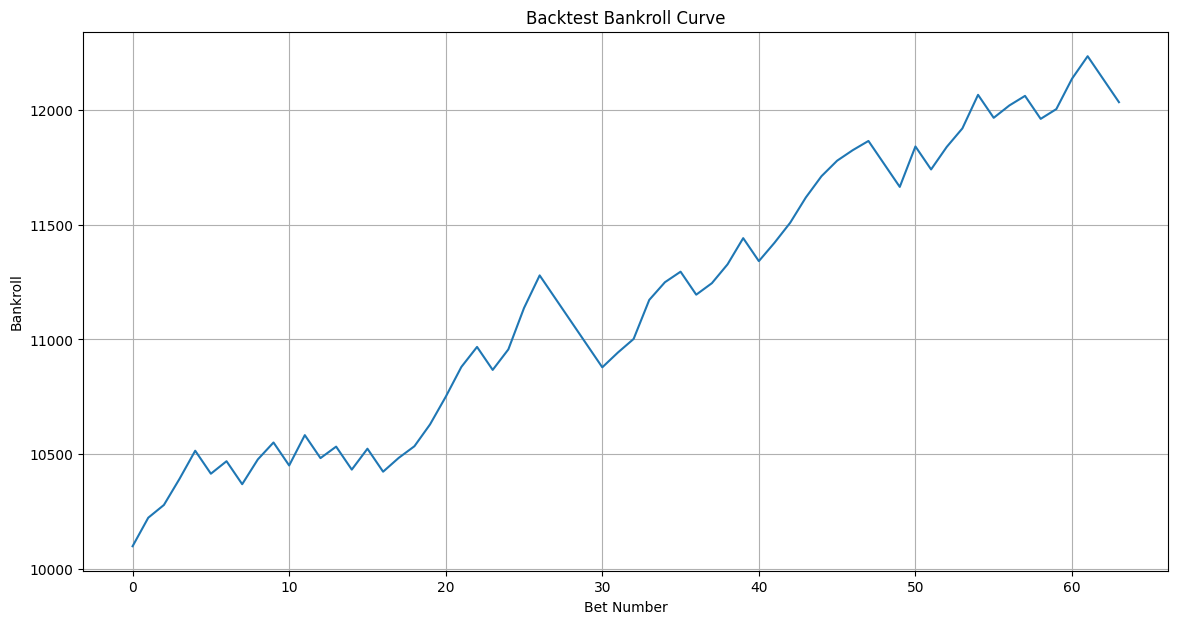

In [ ]:
# ============================================================
# SECTION 19 — BANKROLL CURVE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(
    flat_bets["bankroll_curve"]
)

plt.title("Backtest Bankroll Curve")
plt.xlabel("Bet Number")
plt.ylabel("Bankroll")

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# SECTION 20 — MONTHLY PERFORMANCE ANALYSIS
# ============================================================

flat_bets["year_month"] = (
    flat_bets["date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_results = flat_bets.groupby(
    "year_month",
    observed=False
).agg(
    bets=("bet_won", "count"),
    wins=("bet_won", "sum"),
    profit=("profit", "sum")
).reset_index()

monthly_results["losses"] = (
    monthly_results["bets"]
    -
    monthly_results["wins"]
)

monthly_results["win_rate"] = (
    monthly_results["wins"]
    /
    monthly_results["bets"]
) * 100

monthly_results["risked"] = (
    monthly_results["bets"] * 100
)

monthly_results["roi"] = (
    monthly_results["profit"]
    /
    monthly_results["risked"]
) * 100

monthly_results = monthly_results.sort_values(
    "year_month"
)

monthly_results

,year_month,bets,wins,profit,losses,win_rate,risked,roi
0,2023-02,1,1,100.000000,0,100.000000,100,100.000000
1,2023-03,2,2,179.555556,0,100.000000,200,89.777778
2,2023-04,2,2,236.000000,0,100.000000,200,118.000000
3,2023-05,5,3,35.877238,2,60.000000,500,7.175448
4,2023-06,2,1,32.000000,1,50.000000,200,16.000000
5,2023-07,5,2,-159.090909,3,40.000000,500,-31.818182
6,2023-08,1,1,60.240964,0,100.000000,100,60.240964
7,2023-09,4,4,395.743146,0,100.000000,400,98.935786
8,2023-12,1,1,86.956522,0,100.000000,100,86.956522
9,2024-01,4,3,311.285714,1,75.000000,400,77.821429


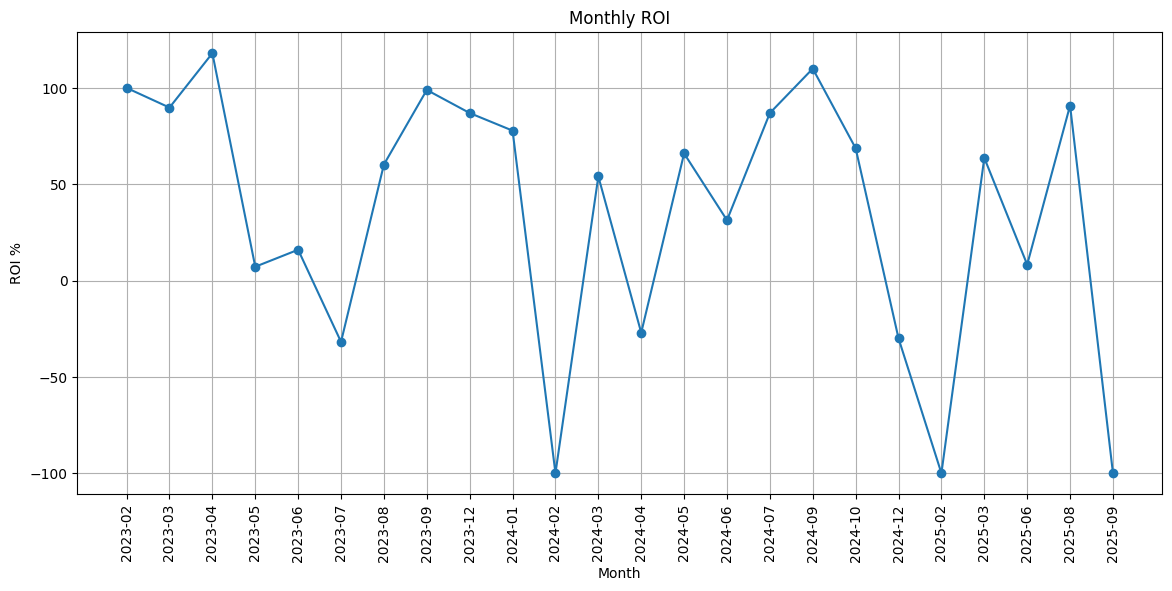

In [ ]:
# ============================================================
# SECTION 21 — MONTHLY ROI CHART
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_results["year_month"],
    monthly_results["roi"],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Monthly ROI")
plt.xlabel("Month")
plt.ylabel("ROI %")

plt.grid(True)

plt.show()

In [ ]:
import xgboost as xgb

In [ ]:
# ============================================================
# SECTION 22 — WALK-FORWARD YEARLY TEST
# ============================================================

walkforward_results = []

years = sorted(
    backtest_df["date"].dt.year.unique()
)

for test_year in years:

    # skip early years
    if test_year < 2016:
        continue

    print(f"\n========== TEST YEAR {test_year} ==========")

    # --------------------------------------------------------
    # TRAIN SPLIT
    # --------------------------------------------------------

    train_df = backtest_df[
        backtest_df["date"].dt.year < test_year
    ].copy()

    test_df = backtest_df[
        backtest_df["date"].dt.year == test_year
    ].copy()

    print("Train fights:", len(train_df))
    print("Test fights:", len(test_df))

    if len(test_df) < 50:
        continue

    # --------------------------------------------------------
    # FEATURES
    # --------------------------------------------------------

    X_train = train_df[feature_columns]
    y_train = train_df["actual_red_win"]

    X_test = test_df[feature_columns]
    y_test = test_df["actual_red_win"]

    # --------------------------------------------------------
    # TRAIN MODEL
    # --------------------------------------------------------

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    test_df["model_red_prob"] = (
        model.predict_proba(X_test)[:, 1]
    )

    test_df["model_blue_prob"] = (
        1 - test_df["model_red_prob"]
    )

    test_df["confidence"] = (
        test_df[[
            "model_red_prob",
            "model_blue_prob"
        ]].max(axis=1)
        * 100
    )

    # --------------------------------------------------------
    # PICK SIDE
    # --------------------------------------------------------

    test_df["best_side"] = np.where(
        test_df["model_red_prob"]
        >=
        test_df["model_blue_prob"],
        "RED",
        "BLUE"
    )

    test_df["best_prob"] = test_df[[
        "model_red_prob",
        "model_blue_prob"
    ]].max(axis=1)

    # --------------------------------------------------------
    # IMPLIED PROBS
    # --------------------------------------------------------

    test_df["red_implied_prob"] = (
        1 / test_df["red_decimal_odds"]
    )

    test_df["blue_implied_prob"] = (
        1 / test_df["blue_decimal_odds"]
    )

    test_df["best_implied_prob"] = np.where(
        test_df["best_side"] == "RED",
        test_df["red_implied_prob"],
        test_df["blue_implied_prob"]
    )

    test_df["best_edge"] = (
        test_df["best_prob"]
        -
        test_df["best_implied_prob"]
    )

    # --------------------------------------------------------
    # EV
    # --------------------------------------------------------

    test_df["red_ev"] = (
        test_df["model_red_prob"]
        *
        (test_df["red_decimal_odds"] - 1)
        -
        (1 - test_df["model_red_prob"])
    )

    test_df["blue_ev"] = (
        test_df["model_blue_prob"]
        *
        (test_df["blue_decimal_odds"] - 1)
        -
        (1 - test_df["model_blue_prob"])
    )

    test_df["best_ev"] = np.where(
        test_df["best_side"] == "RED",
        test_df["red_ev"],
        test_df["blue_ev"]
    )

    # --------------------------------------------------------
    # BEST ODDS
    # --------------------------------------------------------

    test_df["best_odds"] = np.where(
        test_df["best_side"] == "RED",
        test_df["red_odds"],
        test_df["blue_odds"]
    )

    test_df["best_decimal_odds"] = np.where(
        test_df["best_side"] == "RED",
        test_df["red_decimal_odds"],
        test_df["blue_decimal_odds"]
    )

    # --------------------------------------------------------
    # WIN FLAG
    # --------------------------------------------------------

    test_df["bet_won"] = np.where(
        (
            (test_df["best_side"] == "RED")
            &
            (test_df["actual_red_win"] == 1)
        )
        |
        (
            (test_df["best_side"] == "BLUE")
            &
            (test_df["actual_red_win"] == 0)
        ),
        1,
        0
    )

    # --------------------------------------------------------
    # FILTERS
    # --------------------------------------------------------

    bets = test_df[
        (test_df["best_edge"] >= 0.05)
        &
        (test_df["best_ev"] >= 0.05)
        &
        (test_df["confidence"] >= 70)
        &
        (test_df["best_odds"] >= -250)
        &
        (test_df["best_odds"] <= 200)
    ].copy()

    if len(bets) == 0:
        continue

    # --------------------------------------------------------
    # PROFIT
    # --------------------------------------------------------

    bets["profit"] = np.where(
        bets["bet_won"] == 1,
        100 * (bets["best_decimal_odds"] - 1),
        -100
    )

    total_profit = bets["profit"].sum()

    total_risked = len(bets) * 100

    roi = (
        total_profit
        /
        total_risked
    ) * 100

    walkforward_results.append({
        "year": test_year,
        "bets": len(bets),
        "wins": bets["bet_won"].sum(),
        "win_rate": bets["bet_won"].mean() * 100,
        "profit": total_profit,
        "roi": roi
    })

# ============================================================
# RESULTS
# ============================================================

walkforward_df = pd.DataFrame(
    walkforward_results
)

walkforward_df


========== TEST YEAR 2016 ==========
Train fights: 2063
Test fights: 448

========== TEST YEAR 2017 ==========
Train fights: 2511
Test fights: 406

========== TEST YEAR 2018 ==========
Train fights: 2917
Test fights: 436

========== TEST YEAR 2019 ==========
Train fights: 3353
Test fights: 456

========== TEST YEAR 2020 ==========
Train fights: 3809
Test fights: 405

========== TEST YEAR 2021 ==========
Train fights: 4214
Test fights: 469

========== TEST YEAR 2022 ==========
Train fights: 4683
Test fights: 477

========== TEST YEAR 2023 ==========
Train fights: 5160
Test fights: 415

========== TEST YEAR 2024 ==========
Train fights: 5575
Test fights: 381

========== TEST YEAR 2025 ==========
Train fights: 5956
Test fights: 343


,year,bets,wins,win_rate,profit,roi
0,2016,92,60,65.217391,1372.399442,14.917385
1,2017,37,29,78.378378,1583.666271,42.801791
2,2018,51,27,52.941176,-173.087005,-3.393863
3,2019,37,16,43.243243,-891.875665,-24.104748
4,2020,27,15,55.555556,142.711960,5.285628
5,2021,31,20,64.516129,230.768209,7.444136
6,2022,21,13,61.904762,33.305931,1.585997
7,2023,25,18,72.000000,619.506086,24.780243
8,2024,21,13,61.904762,-21.143705,-1.006843
9,2025,19,12,63.157895,322.991402,16.999547


In [ ]:
# ============================================================
# SECTION — KELLY STAKING BACKTEST
# ============================================================

STARTING_BANKROLL = 10000

KELLY_FRACTION = 0.50      # 0.25 = quarter Kelly, 0.50 = half Kelly
MAX_STAKE_PCT = 0.03      # max 5% bankroll on one bet
MIN_STAKE = 5             # skip tiny bets below this

kelly_bets = flat_bets.copy().sort_values("date").reset_index(drop=True)

bankroll = STARTING_BANKROLL
bankroll_history = []
stake_history = []
kelly_fraction_history = []
profit_history = []

for _, row in kelly_bets.iterrows():

    p = row["best_prob"]
    decimal_odds = row["best_decimal_odds"]
    b = decimal_odds - 1

    # Kelly formula:
    # f* = (bp - q) / b
    # where q = 1 - p
    q = 1 - p

    full_kelly = ((b * p) - q) / b

    # Never allow negative Kelly
    full_kelly = max(full_kelly, 0)

    # Fractional Kelly
    stake_pct = full_kelly * KELLY_FRACTION

    # Cap max bet size
    stake_pct = min(stake_pct, MAX_STAKE_PCT)

    stake = bankroll * stake_pct

    # Skip tiny calculated bets
    if stake < MIN_STAKE:
        profit = 0
        stake = 0
    else:
        if row["bet_won"] == 1:
            profit = stake * (decimal_odds - 1)
        else:
            profit = -stake

    bankroll += profit

    bankroll_history.append(bankroll)
    stake_history.append(stake)
    kelly_fraction_history.append(stake_pct)
    profit_history.append(profit)


kelly_bets["kelly_stake"] = stake_history
kelly_bets["kelly_stake_pct"] = kelly_fraction_history
kelly_bets["kelly_profit"] = profit_history
kelly_bets["kelly_bankroll"] = bankroll_history

kelly_total_profit = (
    kelly_bets["kelly_bankroll"].iloc[-1]
    -
    STARTING_BANKROLL
)

kelly_total_risked = kelly_bets["kelly_stake"].sum()

kelly_roi = (
    kelly_total_profit
    /
    kelly_total_risked
) * 100 if kelly_total_risked > 0 else 0

kelly_win_rate = (
    kelly_bets["bet_won"].mean()
) * 100 if len(kelly_bets) > 0 else 0

print("Kelly Backtest")
print("--------------")
print("Starting Bankroll:", round(STARTING_BANKROLL, 2))
print("Ending Bankroll:", round(kelly_bets["kelly_bankroll"].iloc[-1], 2))
print("Profit:", round(kelly_total_profit, 2))
print("Total Risked:", round(kelly_total_risked, 2))
print("ROI on Risked:", round(kelly_roi, 2), "%")
print("Win Rate:", round(kelly_win_rate, 2), "%")
print("Bets:", len(kelly_bets))

kelly_bets[[
    "date",
    "r_name",
    "b_name",
    "best_side",
    "best_prob",
    "best_odds",
    "bet_won",
    "kelly_stake",
    "kelly_profit",
    "kelly_bankroll"
]].tail()

Kelly Backtest
--------------
Starting Bankroll: 10000
Ending Bankroll: 17888.92
Profit: 7888.92
Total Risked: 27114.0
ROI on Risked: 29.1 %
Win Rate: 68.75 %
Bets: 64


,date,r_name,b_name,best_side,best_prob,best_odds,bet_won,kelly_stake,kelly_profit,kelly_bankroll
59,2025-08-02,Rodolfo Vieira,Tresean Gore,RED,0.909091,-235.0,1,526.256362,223.938877,17765.817595
60,2025-08-16,Lerone Murphy,Aaron Pico,RED,0.900000,132.0,1,532.974528,703.526377,18469.343971
61,2025-08-23,Uran Satybaldiev,Diyar Nurgozhay,RED,0.674897,-102.0,1,554.080319,543.215999,19012.559970
62,2025-09-06,Andreas Gustafsson,Rinat Fakhretdinov,RED,0.674897,-132.0,0,570.376799,-570.376799,18442.183171
63,2025-09-06,Marcin Tybura,Ante Delija,RED,0.674897,-116.0,0,553.265495,-553.265495,17888.917676


In [ ]:
# ============================================================
# SECTION — KELLY MAX DRAWDOWN
# ============================================================

kelly_bets["kelly_peak"] = (
    kelly_bets["kelly_bankroll"].cummax()
)

kelly_bets["kelly_drawdown"] = (
    kelly_bets["kelly_bankroll"]
    -
    kelly_bets["kelly_peak"]
)

kelly_bets["kelly_drawdown_pct"] = (
    kelly_bets["kelly_drawdown"]
    /
    kelly_bets["kelly_peak"]
) * 100

max_kelly_drawdown = kelly_bets["kelly_drawdown"].min()
max_kelly_drawdown_pct = kelly_bets["kelly_drawdown_pct"].min()

print("Kelly Max Drawdown")
print("------------------")
print("Max Drawdown ($):", round(max_kelly_drawdown, 2))
print("Max Drawdown (%):", round(max_kelly_drawdown_pct, 2))

Kelly Max Drawdown
------------------
Max Drawdown ($): -1661.86
Max Drawdown (%): -11.47


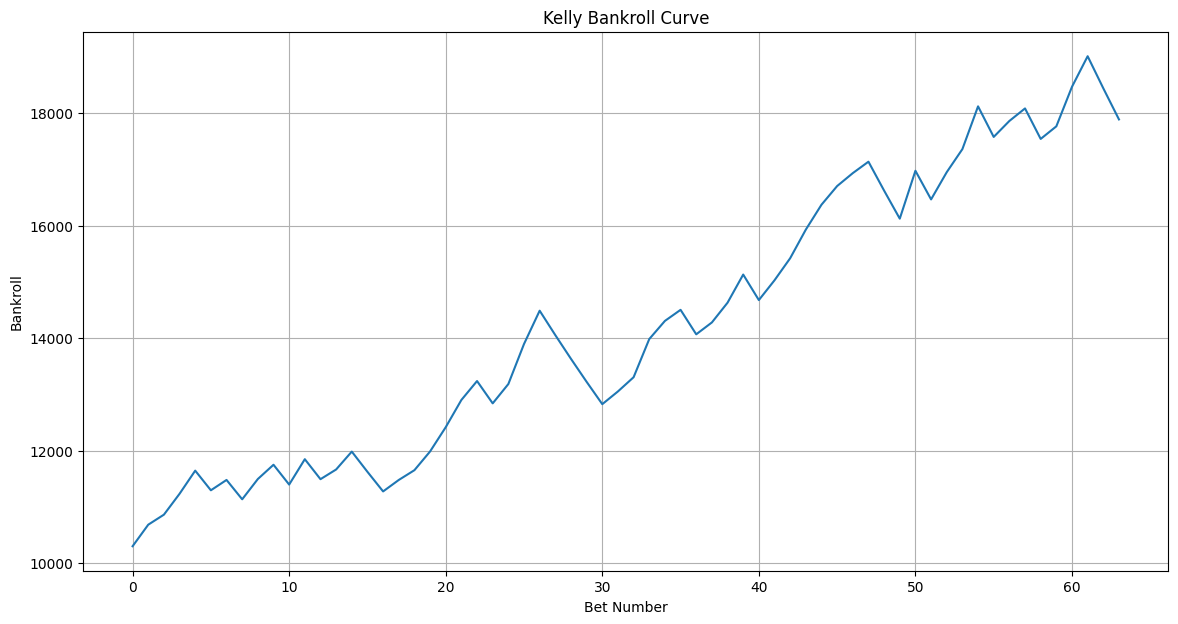

In [ ]:
# ============================================================
# SECTION — KELLY BANKROLL CURVE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(
    kelly_bets["kelly_bankroll"]
)

plt.title("Kelly Bankroll Curve")
plt.xlabel("Bet Number")
plt.ylabel("Bankroll")

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# BACKTEST SUMMARY USING NOTEBOOK VARIABLE NAMES
# ============================================================

summary_rows = []

summary_rows.append({
    "Metric": "Total fights",
    "Value": len(backtest_df)
})

summary_rows.append({
    "Metric": "Prediction accuracy",
    "Value": (backtest_df["model_pick_red"] == backtest_df["actual_red_win"]).mean()
})

summary_rows.append({
    "Metric": "Flat bets",
    "Value": len(flat_bets)
})

summary_rows.append({
    "Metric": "Flat wins",
    "Value": flat_bets["bet_won"].sum()
})

summary_rows.append({
    "Metric": "Flat win rate",
    "Value": flat_bets["bet_won"].mean() if len(flat_bets) > 0 else 0
})

summary_rows.append({
    "Metric": "Flat profit",
    "Value": flat_bets["profit"].sum() if len(flat_bets) > 0 else 0
})

summary_rows.append({
    "Metric": "Flat risked",
    "Value": len(flat_bets) * FLAT_BET_SIZE
})

summary_rows.append({
    "Metric": "Flat ROI",
    "Value": (
        flat_bets["profit"].sum() / (len(flat_bets) * FLAT_BET_SIZE)
        if len(flat_bets) > 0 else 0
    )
})

if "kelly_bets" in globals() and len(kelly_bets) > 0:
    summary_rows.append({
        "Metric": "Kelly bets",
        "Value": len(kelly_bets)
    })

    summary_rows.append({
        "Metric": "Kelly ending bankroll",
        "Value": kelly_bets["kelly_bankroll"].iloc[-1]
    })

    summary_rows.append({
        "Metric": "Kelly profit",
        "Value": kelly_bets["kelly_profit"].sum()
    })

    summary_rows.append({
        "Metric": "Kelly risked",
        "Value": kelly_bets["kelly_stake"].sum()
    })

    summary_rows.append({
        "Metric": "Kelly ROI",
        "Value": (
            kelly_bets["kelly_profit"].sum() / kelly_bets["kelly_stake"].sum()
            if kelly_bets["kelly_stake"].sum() > 0 else 0
        )
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Metric,Value
0,Total fights,6299.000000
1,Prediction accuracy,0.723131
2,Flat bets,64.000000
3,Flat wins,44.000000
4,Flat win rate,0.687500
5,Flat profit,2032.364871
6,Flat risked,6400.000000
7,Flat ROI,0.317557
8,Kelly bets,64.000000
9,Kelly ending bankroll,17888.917676


In [ ]:
# ============================================================
# CALIBRATION AUDIT — CONFIDENCE BUCKETS
# ============================================================

calibration_df = backtest_df.copy()

# Confidence bucket (50-55, 55-60, etc)
calibration_df["confidence_bucket"] = (
    (calibration_df["confidence"] // 5) * 5
).astype(int)

bucket_summary = calibration_df.groupby(
    "confidence_bucket"
).agg(
    fights=("confidence", "count"),
    predicted_confidence=("confidence", "mean"),
    actual_win_rate=("model_pick_red", lambda x: np.nan),  # placeholder
)

# Actual correctness
calibration_df["prediction_correct"] = (
    calibration_df["model_pick_red"]
    == calibration_df["actual_red_win"]
).astype(int)

actuals = calibration_df.groupby(
    "confidence_bucket"
)["prediction_correct"].mean()

bucket_summary["actual_win_rate"] = actuals.values * 100

bucket_summary = bucket_summary.reset_index()

bucket_summary["calibration_error"] = (
    bucket_summary["predicted_confidence"]
    - bucket_summary["actual_win_rate"]
)

display(bucket_summary.sort_values("confidence_bucket"))

,confidence_bucket,fights,predicted_confidence,actual_win_rate,calibration_error
0,50,1171,52.438256,53.373185,-0.934929
1,55,804,57.686030,58.582090,-0.896060
2,60,2273,61.270937,71.051474,-9.780537
3,65,1193,67.465219,85.917854,-18.452635
4,75,205,77.224607,93.170732,-15.946124
5,80,127,82.756137,94.488189,-11.732052
6,85,57,89.999998,98.245614,-8.245616
7,90,76,91.157444,93.421053,-2.263609
8,95,393,97.996439,96.946565,1.049874
